# FWI projections 2026–2045

**SECS — Southern Europe Climate Study** · Seville (Guadalquivir basin) · Larissa (Thessaly plain)

Extends the fire-weather arm from the CEMS historical record (1990–2025) into the CMIP6 projection
window **2026–2045** under SSP5-8.5, using **CMCC-ESM2** daily fields that have been
grid-averaged and bias-corrected against ERA5 by the existing pipeline.

The bias-corrected source file runs to 2061; it is truncated to 2045 here. This is lossless: the
EDCDFm implementation computes each future day's percentile against the model's *historical*
distribution, so a day's correction does not depend on which other future days are present in the
file. Truncating after correction gives the same values as correcting a 2026–2045 file directly.

---

## Method

| Stage | Where it happens |
|---|---|
| Raw CMIP6 pull, per grid point | `pull_cmip6_projections.py` |
| 4-cell grid average, K→°C, RH derivation | `cmip6_grid_processing.py` |
| EDCDFm bias correction vs ERA5, per month | `bias_correct_cmip6_projection.py` |
| FWI computation | `fwi_from_daily.py` (imported below) |

FWI is computed here rather than downloaded because no pre-computed fire-danger projection is
consistent with this study's model run — the CDS products derive from EURO-CORDEX regional models
under RCP forcing. Computing from the same daily fields that drive the heat indicators keeps both
arms describing one simulated future.

## Inputs, and why each is the right one

All four FWI drivers come from the bias-corrected file:

| FWI needs | Column | Note |
|---|---|---|
| noon temperature | `tmax_c` | close to the noon-to-mid-afternoon peak |
| noon relative humidity | `rh_min_percent` | derived at `tasmax`, so it is the daily *minimum* RH |
| noon wind | `wind_avg` | **real projected wind** — CMCC-ESM2 publishes daily `sfcWind` |
| 24 h precipitation | `precip_mm_day` | multiplicative correction, guards against negatives |

Two of these deserve emphasis:

**Wind is real, not substituted.** An earlier plan held wind at ERA5 climatology on the assumption
that the model published no daily wind under SSP scenarios. That is true of EC-Earth3-CC; it is not
true of CMCC-ESM2, which is the model actually in use. Projected wind is used directly and there is
no wind caveat.

**RH is the minimum, not the mean.** `rh_min_percent` is derived by evaluating humidity at daily
maximum temperature. This matters more than it sounds: in ERA5 at Seville the ratio
`rh_min/rh_mean` runs 0.652 in July against 0.855 in December, so feeding daily-mean RH would
overstate summer humidity by roughly 50% and suppress projected fire danger badly. The variable is
bias-corrected in its own right rather than rescaled after the fact.

## What is reported, and what is not

`days_fwi_gt30` — annual days above the EFFIS "high" threshold — is the headline. It validates
against CEMS at r ≈ 0.96.

**Persistence metrics are not reported for the projection.** Longest consecutive high-danger run
validated at r = 0.78 with a +14 day bias, and a 5-day spell count at r = 0.57. Section 3
reproduces that finding. Persistence appears only in the historical record, sourced from CEMS.

## 0. Setup

In [2]:
import os
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

warnings.filterwarnings("ignore", category=FutureWarning)

DATA = "data"
FIGS = "figures"
os.makedirs(FIGS, exist_ok=True)

SITES = {
    "seville": {
        "lat": 37.39, "colour": "#E8A33D", "label": "Seville",
        "era5": "eda_results/eda_outputs/seville_daily.csv",
        "cems": f"{DATA}/seville_fwi_daily_1990_2025.csv",
    },
    "larissa": {
        "lat": 39.64, "colour": "#3D9E8F", "label": "Larissa",
        "era5": "eda_results/eda_outputs_larissa/larissa_daily.csv",
        "cems": f"{DATA}/larissa_fwi_daily_1990_2025.csv",
    },
}

SCENARIO = "ssp585"
SCENARIO_LABEL = "SSP5-8.5"
MODEL = "CMCC-ESM2"

# Bias-corrected projection column names
PROJ_MAP = {"tasmax": "tmax_c", "pr": "precip_mm_day"}
PROJ_RH = "rh_min_percent"
PROJ_WIND = "wind_avg"

# ERA5 EDA-output column names (same names, conveniently)
ERA5_MAP = {"tasmax": "tmax_c", "pr": "precip_mm_scaled"}
ERA5_RH = "rh_min_percent"
ERA5_WIND = "wind_avg"

FWI_THRESHOLD = 30.0          # EFFIS "high"
SPINUP_DAYS = 365
PROJ_START, PROJ_END = 2026, 2045      # source file runs to 2061; truncated here
PERIODS = {"2026-2035": (2026, 2035), "2036-2045": (2036, 2045),
           "2026-2045": (2026, 2045)}

print("pandas", pd.__version__, "| numpy", np.__version__)

pandas 3.0.5 | numpy 2.5.1


In [3]:
sys.path.insert(0, os.getcwd())
import fwi_from_daily as F
import importlib; importlib.reload(F)

import xclim
print("xclim", xclim.__version__)
print("module:", F.__file__)
assert hasattr(F, "compute_fwi"), "fwi_from_daily.py is missing compute_fwi"

xclim 0.61.1
module: c:\Users\mohan\Desktop\Neuefische_Bootcamp\Capstone-project\SECS_capstone_project\fwi_from_daily.py


In [4]:
def inventory(path):
    if os.path.exists(path):
        d = pd.read_csv(path, nrows=1)
        print(f"  OK      {path}")
        print(f"          {list(d.columns)}")
        return True
    print(f"  MISSING {path}")
    return False

print("ERA5 (validation inputs + fitting reference)")
for city, cfg in SITES.items():
    inventory(cfg["era5"])

print("\nCEMS historical FWI (validation target)")
have_cems = {city: inventory(cfg["cems"]) for city, cfg in SITES.items()}

print("\nBias-corrected CMIP6 projections")
have_proj = {}
for city in SITES:
    p = f"{DATA}/{city}_cmip6_{SCENARIO}_2026_2061_biascorrected.csv"
    have_proj[city] = inventory(p)

ERA5 (validation inputs + fitting reference)
  OK      eda_results/eda_outputs/seville_daily.csv
          ['valid_time', 'tmax_c', 'tmin_c', 'tmean_c', 'precip_mm', 'precip_mm_scaled', 'wind_avg', 'wind_max', 'd2m_celsius', 'rh_mean_percent', 'rh_min_percent', 'heat_index_max_c', 'dtr_c', 'year', 'month', 'season', 'is_wet']
  OK      eda_results/eda_outputs_larissa/larissa_daily.csv
          ['valid_time', 'tmax_c', 'tmin_c', 'tmean_c', 'precip_mm', 'precip_mm_scaled', 'wind_avg', 'wind_max', 'd2m_celsius', 'rh_mean_percent', 'rh_min_percent', 'heat_index_max_c', 'dtr_c', 'year', 'month', 'season', 'is_wet']

CEMS historical FWI (validation target)
  OK      data/seville_fwi_daily_1990_2025.csv
          ['date', 'city', 'build_up_index', 'drought_code', 'fine_fuel_moisture_code', 'fire_weather_index', 'initial_fire_spread_index']
  MISSING data/larissa_fwi_daily_1990_2025.csv

Bias-corrected CMIP6 projections
  OK      data/seville_cmip6_ssp585_2026_2061_biascorrected.csv
         

## 1. Validation — FWI on ERA5, against CEMS

The gate. Everything downstream is only meaningful if the implementation reproduces the CEMS
series on inputs where both exist.

Note the input asymmetry, which is worth stating rather than glossing: ERA5 supplies
`rh_min_percent` directly, while the projection derives its equivalent from specific humidity,
pressure and `tasmax` inside `cmip6_grid_processing.py`. Both target daily-minimum RH, so this
validates the FWI implementation but not the RH derivation itself.

In [5]:
validations = {}

for city, cfg in SITES.items():
    if not os.path.exists(cfg["era5"]):
        print(f"[skip] {city}: no ERA5 file")
        continue

    print(f"\n=== {cfg['label']} ===")
    era5 = pd.read_csv(cfg["era5"], parse_dates=["valid_time"]).set_index("valid_time")
    era5 = era5.sort_index()
    tmp = f"{DATA}/_tmp_{city}_era5_for_fwi.csv"
    era5.to_csv(tmp)

    w = F.prepare(daily_csv=tmp, wind_csv=None, city=city,
                  colmap={**F.DEFAULT_MAP, **ERA5_MAP},
                  rh_col=ERA5_RH, wind_col=ERA5_WIND, wind_units="m/s")
    v = F.compute_fwi(w, lat=cfg["lat"]).iloc[SPINUP_DAYS:]
    v.to_csv(f"{DATA}/{city}_fwi_era5_validation.csv", float_format="%.4f")
    validations[city] = v
    os.remove(tmp)
    print(f"  -> {DATA}/{city}_fwi_era5_validation.csv  ({len(v)} rows)")


=== Seville ===
[prepare] humidity: column 'rh_min_percent' used directly
[prepare] wind: column 'wind_avg' x3.6 -> km/h
[prepare] 13149 days  1990-01-01 -> 2025-12-31
          tasmax  mean 23.4 degC
          hurs    mean 48.4 %
          wind    mean 9.0 km/h  (climatology)
          precip  mean 1.33 mm/day
  -> data/seville_fwi_era5_validation.csv  (12784 rows)

=== Larissa ===
[prepare] humidity: column 'rh_min_percent' used directly
[prepare] wind: column 'wind_avg' x3.6 -> km/h
[prepare] 13149 days  1990-01-01 -> 2025-12-31
          tasmax  mean 21.0 degC
          hurs    mean 48.0 %
          wind    mean 5.7 km/h  (climatology)
          precip  mean 1.70 mm/day
  -> data/larissa_fwi_era5_validation.csv  (12784 rows)


In [6]:
PAIRS = [("fwi", "fire_weather_index"),
         ("dc", "drought_code"),
         ("ffmc", "fine_fuel_moisture_code"),
         ("bui", "build_up_index"),
         ("isi", "initial_fire_spread_index")]

validation_tables = {}
overlaps = {}

for city, cfg in SITES.items():
    if city not in validations or not have_cems.get(city):
        print(f"[skip] {cfg['label']}: no CEMS record to validate against")
        continue

    cems = pd.read_csv(cfg["cems"], index_col=0, parse_dates=True)
    j = validations[city][[a for a, _ in PAIRS]].join(
            cems[[b for _, b in PAIRS]], how="inner").dropna()
    overlaps[city] = j

    rows = [{"code": a, "r": round(j[a].corr(j[b]), 3),
             "mine_mean": round(j[a].mean(), 2),
             "cems_mean": round(j[b].mean(), 2),
             "bias": round(j[a].mean() - j[b].mean(), 2)} for a, b in PAIRS]
    t = pd.DataFrame(rows).set_index("code")
    validation_tables[city] = t

    print(f"\n{cfg['label']}: {len(j)} overlapping days "
          f"({j.index.min().date()} -> {j.index.max().date()})")
    display(t)

    r_fwi, b_fwi = t.loc["fwi", "r"], t.loc["fwi", "bias"]
    r_dc = t.loc["dc", "r"]
    verdict = "PASS" if (r_dc >= 0.95 and r_fwi >= 0.85) else "REVIEW"
    print(f"  {verdict}: dc r={r_dc:.3f}, fwi r={r_fwi:.3f}, fwi bias={b_fwi:+.2f}")
    print(f"  >>> methods line: r = {r_fwi:.2f}, mean offset = {b_fwi:+.2f} FWI units")


Seville: 12784 overlapping days (1991-01-01 -> 2025-12-31)


,r,mine_mean,cems_mean,bias
code,,,,
fwi,0.969,20.20,19.84,0.36
dc,0.987,555.84,539.97,15.87
ffmc,0.929,83.35,82.91,0.44
bui,0.971,139.93,134.83,5.10
isi,0.931,6.15,6.17,-0.02


  PASS: dc r=0.987, fwi r=0.969, fwi bias=+0.36
  >>> methods line: r = 0.97, mean offset = +0.36 FWI units
[skip] Larissa: no CEMS record to validate against


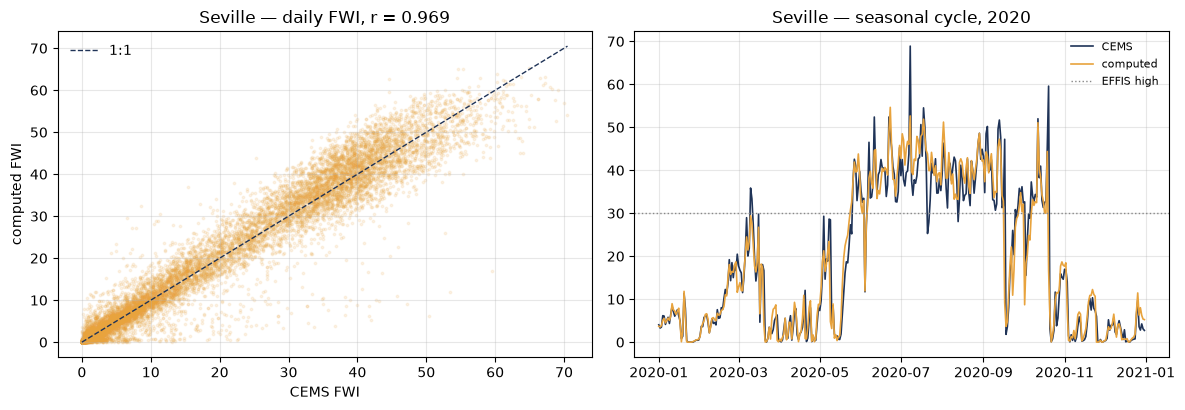

In [7]:
if overlaps:
    n = len(overlaps)
    fig, axes = plt.subplots(n, 2, figsize=(12, 4.2 * n), squeeze=False)
    for row, (city, j) in enumerate(overlaps.items()):
        r = validation_tables[city].loc["fwi", "r"]
        ax = axes[row][0]
        ax.scatter(j["fire_weather_index"], j["fwi"], s=3, alpha=.12,
                   color=SITES[city]["colour"])
        lim = [0, max(j["fwi"].max(), j["fire_weather_index"].max())]
        ax.plot(lim, lim, color="#1F3357", lw=1, ls="--", label="1:1")
        ax.set_xlabel("CEMS FWI"); ax.set_ylabel("computed FWI")
        ax.set_title(f"{SITES[city]['label']} — daily FWI, r = {r:.3f}")
        ax.legend(frameon=False); ax.grid(alpha=.3)

        ax = axes[row][1]
        yr = j.index.year.max() - 5
        s = j.loc[str(yr)]
        ax.plot(s.index, s["fire_weather_index"], lw=1.2, color="#1F3357", label="CEMS")
        ax.plot(s.index, s["fwi"], lw=1.2, color=SITES[city]["colour"], label="computed")
        ax.axhline(FWI_THRESHOLD, color="#888", ls=":", lw=1, label="EFFIS high")
        ax.set_title(f"{SITES[city]['label']} — seasonal cycle, {yr}")
        ax.legend(frameon=False, fontsize=8); ax.grid(alpha=.3)

    plt.tight_layout(); plt.savefig(f"{FIGS}/fwi_validation.png", dpi=150); plt.show()

## 2. Annual indicators — which metrics survive validation

Daily correlation is reassuring, but the study reports annual quantities. This is where the
persistence problem shows up, and it is the reason `longest_high_run` does not appear in the
projection results.

In [8]:
def spell_count(x, threshold=FWI_THRESHOLD, min_len=5):
    "Number of distinct stretches of >= min_len consecutive days above threshold."
    above = (x > threshold).astype(int).values
    n = run = 0
    for v in above:
        run = run + 1 if v else 0
        if run == min_len:
            n += 1
    return n


def metric_agreement(j):
    rows = []
    for yr in sorted(set(j.index.year)):
        s = j.loc[str(yr)]
        rows.append({
            "year": yr,
            "days_mine": int((s["fwi"] > FWI_THRESHOLD).sum()),
            "days_cems": int((s["fire_weather_index"] > FWI_THRESHOLD).sum()),
            "run_mine": F.annual_indicators(s.rename(columns={"fwi": "fwi"})[["fwi"]])
                          ["longest_high_run"].iloc[0],
            "run_cems": F.annual_indicators(
                s[["fire_weather_index"]].rename(columns={"fire_weather_index": "fwi"}))
                          ["longest_high_run"].iloc[0],
            "spell_mine": spell_count(s["fwi"]),
            "spell_cems": spell_count(s["fire_weather_index"]),
        })
    return pd.DataFrame(rows).set_index("year")


agreement = {}
for city, j in overlaps.items():
    a = metric_agreement(j)
    agreement[city] = a
    print(f"\n{SITES[city]['label']}")
    for m in ["days", "run", "spell"]:
        r = a[f"{m}_mine"].corr(a[f"{m}_cems"])
        b = (a[f"{m}_mine"] - a[f"{m}_cems"]).mean()
        keep = "KEEP" if r >= 0.85 else "DROP"
        print(f"  {m:6s} r = {r:6.3f}  bias = {b:+6.1f}   -> {keep}")


Seville
  days   r =  0.957  bias =   +3.3   -> KEEP
  run    r =  0.776  bias =  +14.3   -> DROP
  spell  r =  0.572  bias =   -0.6   -> DROP


**Why persistence fails.** Run length integrates the slow moisture codes. A small persistent
difference in drying — the drought-code bias is roughly 3% — compounds across a season into a large
difference in how long a stretch stays unbroken, while daily FWI correlation stays high. The
disagreement does not track near-threshold day counts (r ≈ 0.09 against that), so it is not simple
threshold brittleness; the sign also flips between years, which a constant offset cannot produce.

Spell counting degrades more gracefully in principle but validated no better in practice.

**Consequence:** report `days_fwi_gt30`. State the persistence finding as a limitation rather than
reporting a number that does not hold up. That is a stronger methods position than quietly
publishing the run length.

## 3. Warm start from CEMS

FWI is sequential and the drought code carries months of memory, so a cold start contaminates the
first season. Where CEMS covers the end of 2025, the projection is initialised from its codes,
removing the discontinuity at the historical/projection seam.

CEMS supplies DC, FFMC and BUI but not DMC. DMC is recovered by inverting the BUI relation; where
that inversion is ill-conditioned the xclim default is used and the spin-up discard absorbs the
residual. Note the CEMS codes carry their own bias correction, so a warm start sits on a slightly
shifted scale — still better than an arbitrary cold one.

In [9]:
def warm_start_codes(city, on="2025-12-31"):
    cfg = SITES[city]
    if not have_cems.get(city):
        print(f"[{city}] no CEMS record -> cold start + {SPINUP_DAYS}d discard")
        return None, None, None
    cems = pd.read_csv(cfg["cems"], index_col=0, parse_dates=True)
    try:
        row = cems.loc[on]
    except KeyError:
        print(f"[{city}] {on} not in CEMS -> cold start")
        return None, None, None

    dc0 = float(row["drought_code"])
    ffmc0 = float(row["fine_fuel_moisture_code"])
    bui = float(row["build_up_index"])
    dmc0, denom = None, 0.8 * dc0 - bui
    if denom > 1e-6:
        cand = 0.4 * dc0 * bui / denom
        if 0 < cand < 500:
            dmc0 = float(cand)
    if dmc0 is None:
        print(f"[{city}] DMC inversion ill-conditioned -> xclim default")
    print(f"[{city}] warm start {on}: ffmc0={ffmc0:.2f} "
          f"dmc0={'%.2f' % dmc0 if dmc0 else 'default'} dc0={dc0:.2f}")
    return ffmc0, dmc0, dc0


WARM = {city: warm_start_codes(city) for city in SITES}

[seville] warm start 2025-12-31: ffmc0=72.66 dmc0=1.41 dc0=222.80
[larissa] no CEMS record -> cold start + 365d discard


## 4. Projection runs

In [10]:
projections = {}

for city, cfg in SITES.items():
    src = f"{DATA}/{city}_cmip6_{SCENARIO}_2026_2061_biascorrected.csv"
    if not os.path.exists(src):
        print(f"[skip] {cfg['label']}: {src} not found")
        continue

    print(f"\n=== {cfg['label']} / {SCENARIO_LABEL} / {MODEL} ===")
    ffmc0, dmc0, dc0 = WARM[city]

    # Truncate to the reporting window BEFORE integration, so the FWI codes are
    # not carrying moisture memory from years that will be discarded anyway.
    full = pd.read_csv(src, index_col=0, parse_dates=True).sort_index()
    trunc = full.loc[str(PROJ_START):str(PROJ_END)]
    print(f"  source {full.index.min().date()}..{full.index.max().date()} "
          f"-> truncated to {trunc.index.min().date()}..{trunc.index.max().date()}")
    src = f"{DATA}/_tmp_{city}_proj_trunc.csv"
    trunc.to_csv(src)

    w = F.prepare(daily_csv=src, wind_csv=None, city=city,
                  colmap={**F.DEFAULT_MAP, **PROJ_MAP},
                  rh_col=PROJ_RH, wind_col=PROJ_WIND, wind_units="m/s")
    out = F.compute_fwi(w, lat=cfg["lat"], ffmc0=ffmc0, dmc0=dmc0, dc0=dc0)
    if ffmc0 is None:
        out = out.iloc[SPINUP_DAYS:]
        print(f"  cold start -> discarded {SPINUP_DAYS} leading days")

    os.remove(src)
    dst = f"{DATA}/{city}_fwi_{SCENARIO}_{PROJ_START}_{PROJ_END}.csv"
    out.to_csv(dst, float_format="%.4f")
    projections[city] = out
    print(f"  -> {dst}  ({len(out)} rows, "
          f"{out.index.min().date()} to {out.index.max().date()})")


=== Seville / SSP5-8.5 / CMCC-ESM2 ===
  source 2026-01-01..2061-12-31 -> truncated to 2026-01-01..2045-12-31
[prepare] humidity: column 'rh_min_percent' used directly
[prepare] wind: column 'wind_avg' x3.6 -> km/h
[prepare] 7300 days  2026-01-01 -> 2045-12-31
          tasmax  mean 24.4 degC
          hurs    mean 46.3 %
          wind    mean 9.3 km/h  (climatology)
          precip  mean 1.24 mm/day
  -> data/seville_fwi_ssp585_2026_2045.csv  (7300 rows, 2026-01-01 to 2045-12-31)

=== Larissa / SSP5-8.5 / CMCC-ESM2 ===
  source 2026-01-01..2061-12-31 -> truncated to 2026-01-01..2045-12-31
[prepare] humidity: column 'rh_min_percent' used directly
[prepare] wind: column 'wind_avg' x3.6 -> km/h
[prepare] 7300 days  2026-01-01 -> 2045-12-31
          tasmax  mean 22.9 degC
          hurs    mean 44.6 %
          wind    mean 5.6 km/h  (climatology)
          precip  mean 1.25 mm/day
  cold start -> discarded 365 leading days
  -> data/larissa_fwi_ssp585_2026_2045.csv  (6935 rows, 2027-

In [11]:
annuals = {}
for city, df in projections.items():
    ann = F.annual_indicators(df, FWI_THRESHOLD)
    ann = ann[["days_fwi_gt30", "fwi_mean", "fwi_p95", "fwi_max"]]   # persistence dropped
    ann.to_csv(f"{DATA}/{city}_fwi_{SCENARIO}_{PROJ_START}_{PROJ_END}_annual.csv")
    annuals[city] = ann
    print(f"{SITES[city]['label']}: {len(ann)} years -> "
          f"{DATA}/{city}_fwi_{SCENARIO}_{PROJ_START}_{PROJ_END}_annual.csv")

if annuals:
    display(pd.concat({SITES[c]["label"]: a for c, a in annuals.items()},
                      axis=1).head(8).round(2))

Seville: 20 years -> data/seville_fwi_ssp585_2026_2045_annual.csv
Larissa: 19 years -> data/larissa_fwi_ssp585_2026_2045_annual.csv


Seville                                Larissa                   \
     days_fwi_gt30 fwi_mean fwi_p95 fwi_max days_fwi_gt30 fwi_mean fwi_p95   
year                                                                         
2026           129    22.67   58.91   66.46           NaN      NaN     NaN   
2027           167    26.75   51.08   57.90          91.0    15.89   45.38   
2028           202    30.04   55.96   62.96          91.0    14.07   41.15   
2029           159    26.57   55.06   60.65         100.0    16.63   48.64   
2030           139    22.16   53.66   68.83          92.0    16.26   42.38   
2031           112    18.52   51.80   59.09         102.0    16.42   41.84   
2032           131    21.57   47.88   56.60         129.0    19.71   44.28   
2033           143    22.00   54.42   63.19         120.0    21.10   53.75   

              
     fwi_max  
year          
2026     NaN  
2027   57.01  
2028   48.32  
2029   57.52  
2030   51.18  
2031   57.71  
2032   53.80  
2033   67.72

## 5. Baseline and change

The baseline must come from **this pipeline**, not from CEMS. Mixing a CEMS-derived historical
figure with an xclim-derived projection would inject the validation offset straight into the
headline change number. Both ends use `{city}_fwi_era5_validation.csv`, computed in section 1.

In [12]:
BASE_START, BASE_END = 1991, 2020    # WMO normal, matches the wind/ERA5 reference

baselines = {}
for city, v in validations.items():
    b = F.annual_indicators(v.loc[str(BASE_START):str(BASE_END)], FWI_THRESHOLD)
    baselines[city] = b
    print(f"{SITES[city]['label']} baseline {BASE_START}-{BASE_END}: "
          f"days_fwi_gt30 mean = {b['days_fwi_gt30'].mean():.1f}")

Seville baseline 1991-2020: days_fwi_gt30 mean = 126.2
Larissa baseline 1991-2020: days_fwi_gt30 mean = 73.7


In [13]:
rows = []
for city, ann in annuals.items():
    base = baselines.get(city)
    if base is None:
        continue
    b0 = base["days_fwi_gt30"].mean()
    for label, (y0, y1) in PERIODS.items():
        sub = ann.loc[(ann.index >= y0) & (ann.index <= y1), "days_fwi_gt30"]
        if sub.empty:
            continue
        rows.append({
            "city": SITES[city]["label"],
            "period": label,
            "baseline_days": round(b0, 1),
            "projected_days": round(sub.mean(), 1),
            "change_days": round(sub.mean() - b0, 1),
            "change_pct": round(100 * (sub.mean() - b0) / b0, 1),
            "interannual_sd": round(sub.std(), 1),
        })

change_table = pd.DataFrame(rows)
display(change_table)
print("\nReport change_pct. Where change_days is smaller than interannual_sd,")
print("say so rather than presenting the difference as a firm projection.")

,city,period,baseline_days,projected_days,change_days,change_pct,interannual_sd
0,Seville,2026-2035,126.2,147.5,21.3,16.9,25.4
1,Seville,2036-2045,126.2,148.4,22.2,17.6,26.0
2,Seville,2026-2045,126.2,148.0,21.8,17.3,25.0
3,Larissa,2026-2035,73.7,108.7,34.9,47.4,16.6
4,Larissa,2036-2045,73.7,113.1,39.4,53.4,26.1
5,Larissa,2026-2045,73.7,111.0,37.3,50.5,21.6



Report change_pct. Where change_days is smaller than interannual_sd,
say so rather than presenting the difference as a firm projection.


In [14]:
def theil_sen(y):
    y = pd.Series(y).dropna()
    if len(y) < 8:
        return dict(slope=np.nan, tau=np.nan, p=np.nan)
    x = np.asarray(y.index, dtype=float)
    slope, intercept, lo, hi = stats.theilslopes(y.values, x, 0.95)
    tau, p = stats.kendalltau(x, y.values)
    return dict(slope=slope, lo=lo, hi=hi, tau=tau, p=p)


rows = []
for city, ann in annuals.items():
    for metric in ["days_fwi_gt30", "fwi_mean", "fwi_p95"]:
        t = theil_sen(ann[metric])
        rows.append({"city": SITES[city]["label"], "metric": metric,
                     "slope_per_decade": round(t["slope"] * 10, 3),
                     "kendall_tau": round(t["tau"], 3),
                     "p_value": round(t["p"], 4)})
trend_table = pd.DataFrame(rows)
display(trend_table)

,city,metric,slope_per_decade,kendall_tau,p_value
0,Seville,days_fwi_gt30,3.167,0.047,0.7702
1,Seville,fwi_mean,-0.197,-0.021,0.9235
2,Seville,fwi_p95,-1.025,-0.116,0.5006
3,Larissa,days_fwi_gt30,5.000,0.206,0.2202
4,Larissa,fwi_mean,2.110,0.251,0.1433
5,Larissa,fwi_p95,0.829,0.053,0.7825


Over a 20-year window the sample is small and p-values will often sit above 0.05 even where the
direction is consistent, so report direction and magnitude first. This mirrors the baseline-model finding from earlier in the project: the trend
is detectable while a naive baseline still wins on forecast skill, and neither result invalidates
the other.

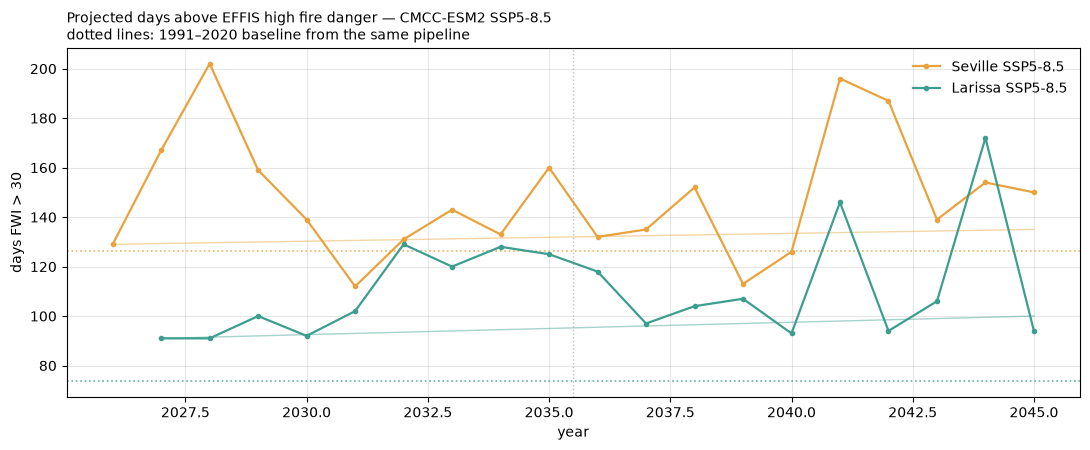

In [15]:
if annuals:
    fig, ax = plt.subplots(figsize=(11, 4.6))
    for city, ann in annuals.items():
        cfg = SITES[city]
        ax.plot(ann.index, ann["days_fwi_gt30"], lw=1.6, marker="o", ms=3,
                color=cfg["colour"], label=f"{cfg['label']} {SCENARIO_LABEL}")
        t = theil_sen(ann["days_fwi_gt30"])
        x = np.asarray(ann.index, dtype=float)
        ax.plot(ann.index, t["slope"] * (x - x[0]) + ann["days_fwi_gt30"].iloc[0],
                color=cfg["colour"], lw=1, alpha=.45)
        if city in baselines:
            ax.axhline(baselines[city]["days_fwi_gt30"].mean(), color=cfg["colour"],
                       ls=":", lw=1.2, alpha=.8)

    ax.axvline(2035.5, color="#999", lw=1, ls=":", alpha=.6)
    ax.set_xlabel("year"); ax.set_ylabel(f"days FWI > {FWI_THRESHOLD:.0f}")
    ax.set_title(f"Projected days above EFFIS high fire danger — {MODEL} {SCENARIO_LABEL}\n"
                 f"dotted lines: {BASE_START}–{BASE_END} baseline from the same pipeline",
                 loc="left", fontsize=10)
    ax.legend(frameon=False); ax.grid(alpha=.3)
    plt.tight_layout(); plt.savefig(f"{FIGS}/fwi_projection_days.png", dpi=150); plt.show()

## 6. Caveats for the slide

Fill bracketed values from the outputs above.

1. **Model and correction.** CMCC-ESM2, SSP5-8.5, four grid cells averaged, bias-corrected against
   ERA5 by Equidistant CDF Matching fit per city, per variable, per calendar month over the
   1990–2014 historical overlap. The method preserves the model's own projected shift rather than
   collapsing it toward historical climatology.

2. **All four FWI drivers are projected.** Including wind — CMCC-ESM2 publishes daily `sfcWind`, so
   nothing is held at climatology.

3. **Humidity is the daily minimum.** `rh_min_percent`, derived at daily maximum temperature and
   bias-corrected as its own variable. Daily-mean RH would have overstated summer humidity by ~50%
   at Seville and suppressed projected fire danger.

4. **Validated, not calibrated.** FWI validated against CEMS 1991–2025: r = **[§1]** on daily FWI,
   r = **[§1]** on drought code, mean offset **[§1]** FWI units. Change figures use a baseline from
   this same pipeline, so the offset cancels.

5. **Persistence not projected.** Longest high-danger run (r = 0.78, +14 day bias) and 5-day spell
   count (r = 0.57) did not reproduce against CEMS. Reported for the historical record only.

6. **One model, one scenario.** No structural or ensemble spread. Directional risk, not calibrated
   magnitude.

7. **Near-term horizon.** 2026–2045 sits before SSP pathways separate meaningfully — the forced
   response differences between scenarios stay small until around mid-century, and much of the gap
   is inside internal variability. This makes a single scenario a defensible choice at this horizon:
   near-term fire-weather risk is largely already committed regardless of emissions path. It also
   means a second scenario would add little here; the bias-corrected source file extends to 2061 if
   a scenario comparison is wanted later.

---

### Follow-ups

- [ ] Confirm whether Larissa has CEMS FWI coverage. If not, the validation and warm start are
      Seville-only and the Larissa projection rests on the Seville-validated implementation —
      state that explicitly.
- [ ] Optional: add SSP2-4.5 for the 2046–2061 comparison. `scenario_scan.py` confirms CMCC-ESM2
      carries ssp1_2_6, ssp2_4_5 and ssp5_8_5 at daily resolution.